# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Catherine Aprilia Harlina | 5054251012 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [27]:
# Import library yang dibutuhkan.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.

df = pd.read_csv('insurance.csv')

In [29]:
# Tampilkan beberapa baris pertama dataset.

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [31]:
# Periksa missing value.
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [32]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [33]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for c in df.select_dtypes(include=['object', 'str']): print(c, '\n', df[c].value_counts(), '\n')

sex 
 sex
male      676
female    662
Name: count, dtype: int64 

smoker 
 smoker
no     1064
yes     274
Name: count, dtype: int64 

region 
 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64 



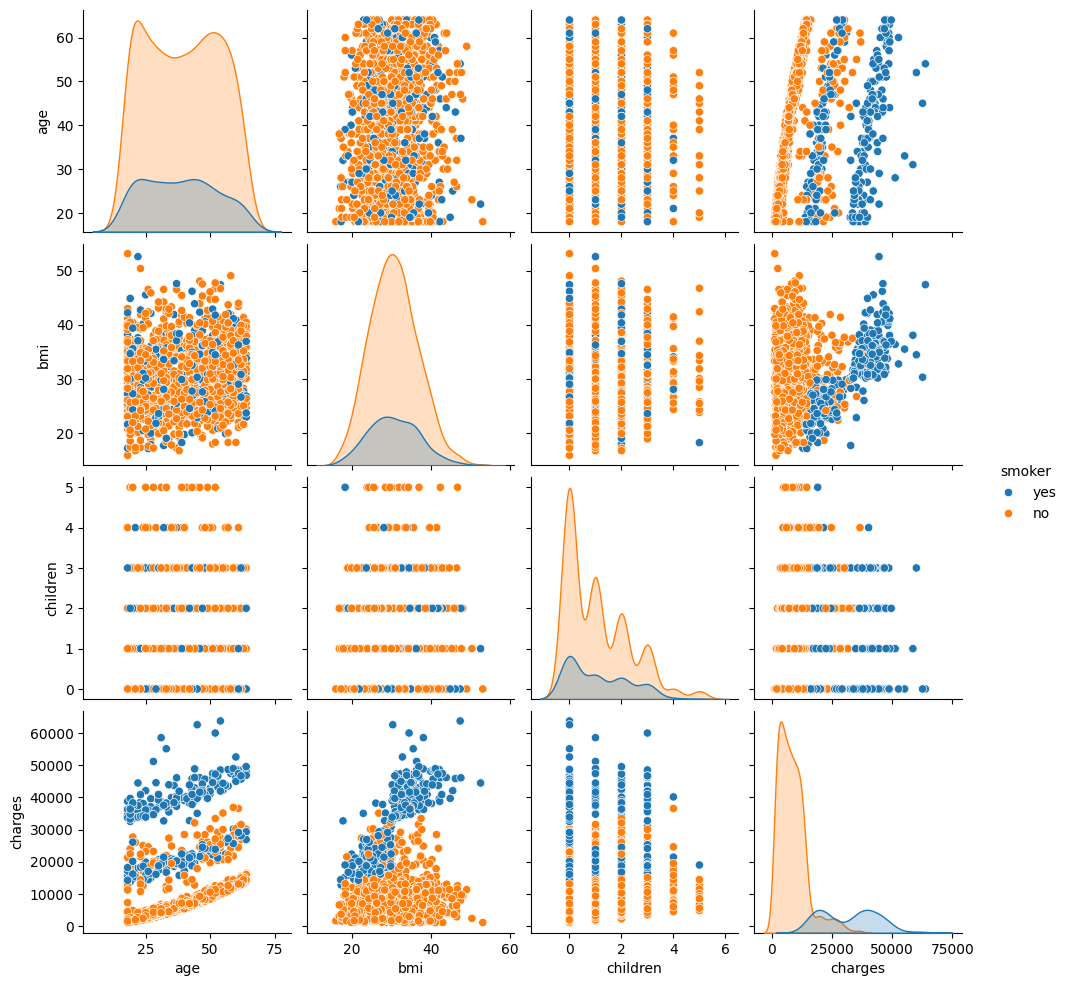

In [34]:
# eda sederhana
sns.pairplot(df, hue='smoker')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [35]:
# Pisahkan fitur (X) dan target (y).
X, y = df.drop(columns=['charges']), df['charges']

In [36]:
# Identifikasi kolom numerik dan kategorikal.
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

In [37]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
preprocessor_scaled = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(drop='first'), cat_cols)])
preprocessor_tree = ColumnTransformer([('num', 'passthrough', num_cols), ('cat', OneHotEncoder(drop='first'), cat_cols)])

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [39]:
# Inisialisasi dan latih Linear Regression.
lr = Pipeline([('prep', preprocessor_scaled), ('reg', LinearRegression())]).fit(X_train, y_train)

In [40]:
# Lakukan prediksi pada test set.
pred_lr = lr.predict(X_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [41]:
# Buat fitur polynomial dan latih model.
poly_prep = ColumnTransformer([('num', Pipeline([('sc', StandardScaler()), ('poly', PolynomialFeatures(degree=2))]), num_cols), ('cat', OneHotEncoder(drop='first'), cat_cols)])
poly = Pipeline([('prep', poly_prep), ('reg', LinearRegression())]).fit(X_train, y_train)

In [42]:
# Lakukan prediksi pada test set.
pred_poly = poly.predict(X_test)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [43]:
# Inisialisasi dan latih Ridge Regression.
ridge = Pipeline([('prep', preprocessor_scaled), ('reg', Ridge(alpha=1.0))]).fit(X_train, y_train)

In [44]:
# Lakukan prediksi pada test set.
pred_ridge = ridge.predict(X_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [45]:
# Inisialisasi dan latih Lasso Regression.
lasso = Pipeline([('prep', preprocessor_scaled), ('reg', Lasso(alpha=10.0))]).fit(X_train, y_train)

In [46]:
# Lakukan prediksi pada test set.
pred_lasso = lasso.predict(X_test)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [47]:
# Inisialisasi dan latih Decision Tree Regressor.
dt = Pipeline([('prep', preprocessor_tree), ('reg', DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42))]).fit(X_train, y_train)

In [48]:
# Lakukan prediksi pada test set.
pred_dt = dt.predict(X_test)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [49]:
# Inisialisasi dan latih SVR.
svr = Pipeline([('prep', preprocessor_scaled), ('reg', SVR(C=1000, epsilon=0.1))]).fit(X_train, y_train)

In [50]:
# Lakukan prediksi pada test set.
pred_svr = svr.predict(X_test)

# 4. Evaluasi Model

In [51]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
models = {'Linear': pred_lr, 'Poly': pred_poly, 'Ridge': pred_ridge, 'Lasso': pred_lasso, 'DT': pred_dt, 'SVR': pred_svr}
res = [{'Model': k, 'MAE': mean_absolute_error(y_test, v), 'MSE': mean_squared_error(y_test, v), 'RMSE': np.sqrt(mean_squared_error(y_test, v)), 'R2': r2_score(y_test, v)} for k, v in models.items()]
pd.DataFrame(res)

,Model,MAE,MSE,RMSE,R2
0,Linear,4181.194474,3.359692e+07,5796.284659,0.783593
1,Poly,4254.274827,3.412055e+07,5841.280186,0.780220
2,Ridge,4193.195353,3.364539e+07,5800.464938,0.783281
3,Lasso,4190.754086,3.368216e+07,5803.633473,0.783044
4,DT,2671.633416,2.041684e+07,4518.499275,0.868490
5,SVR,3433.070028,6.306297e+07,7941.219963,0.593794


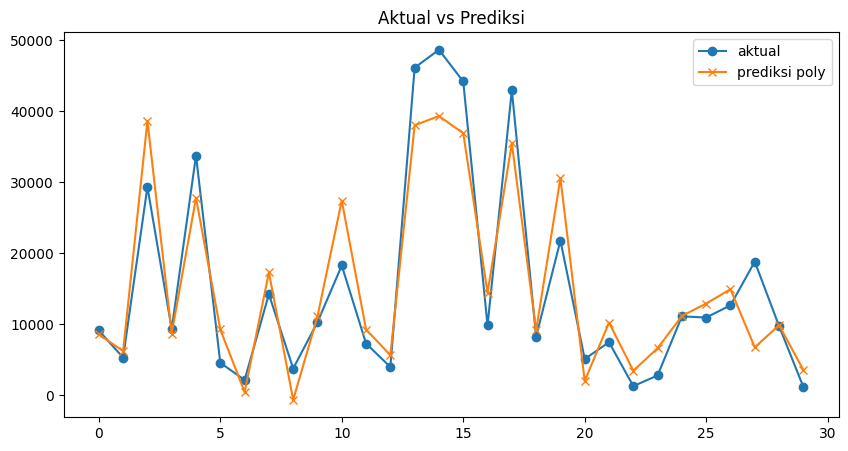

In [52]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:30], label='aktual', marker='o')
plt.plot(pred_poly[:30], label='prediksi poly', marker='x')
plt.legend(); plt.title('Aktual vs Prediksi'); plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


berdasarkn hasil evaluasi model non linear kek Polynomial Regression sm Decision Tree Regressor dapet nilai R2 score yg jauhh lbh tinggi dibnding Linear Regression biasa. hal ini krn relasi antar variabel fitur kaya bmi sm smoker ke target charges emg ga murni linear, jd pas dipakein polynomial features (degree=2) model bsa nangkep interaksi nnon linear antar fitur dngn jauh lbh akurat & presisi

preprocessing kek feature scaling pake StandardScaler ngaruh bgt buat model yg sensitif sm skala jarak kek Ridge, Lasso, sm SVR biar konvergensi ato bobotnya gak didominasi sm variabel bernilai gede doang. sementara buat Decision Tree sbenernya scaling gak gitu ngaruh krn split dasarnya cm murni pake threshold nilai per atribut aja. terus regularisasi di Ridge & Lasso ngebantu banget biar model gak overfitting, tp tetep performanya aga kebentok krn batasan asumsi relasi linear standar data

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


kesimpulannya model terbaik buat predict medical cost ini jatuh ke Polynomial Regression atau Decision Tree Regressor krn emg mmpu nangkep pola non-linear dr data asuransi dg R2 paling tnggi & RMSE terendah

saran kedepannya bsa cobain hyperparameter tuning pake GridSearchCV biar dapet kombinasi max_depth, C, & alpha yg lbh optimal lg, ato nyoba model ensemble kek Random Forest / XGBoost biar pperforma lbh ok & nambahin feature engineering baru dr kombinasi bmi sm status smoker